In [394]:
#Import necessary packages
import time
import requests
import lxml.html as lx
import re
import pandas as pd
from datetime import datetime
import sqlite3 as sql
from requests.exceptions import HTTPError
import operator as op
from unidecode import unidecode
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SQL Overview

In [301]:
#Create SQl connection
sqlite_db_path = '../all_data/data.db'  # Name of the table to be created in SQLite
conn = sql.connect(sqlite_db_path)

OperationalError: unable to open database file

In [ ]:
#View BillboardChart table
pd.read_sql('''SELECT * from BillboardCharts''', conn)

In [ ]:
#View Spotify Weekly Streaming Charts Table
pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts''', conn).head()

In [ ]:
#View Apple Chart Rankings Table
pd.read_sql('''SELECT * FROM AppleChartRankings''', conn).head()

In [ ]:
# View all distinct spotify weekly charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyWeeklyStreamingCharts''', conn)

In [ ]:
#View all distinct spotify daily charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyDailyStreamingCharts''', conn)

In [ ]:
#View all distinct apple charts
pd.read_sql('''SELECT DISTINCT chart_name FROM AppleChartRankings''', conn)

## Ranking Counts

In [ ]:
# Store spotify weekly table for "02-26-2026" week
spotify = pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts WHERE date = "02-26-2026"''', conn)

In [ ]:
# Store billboard global table
global_billboard = pd.read_sql('''SELECT * from BillboardCharts WHERE chart = "Worldwide Top 200 Songs"''', conn)

In [372]:
global_billboard

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Bad Bunny,DTMF,1,https://www.billboard.com/artist/bad-bunny/,1,1,59,02-28-2026,Worldwide Top 200 Songs
1,Bad Bunny,Baile Inolvidable,2,https://www.billboard.com/artist/bad-bunny/,2,2,59,02-28-2026,Worldwide Top 200 Songs
2,Bad Bunny,Nuevayol,3,https://www.billboard.com/artist/bad-bunny/,3,3,59,02-28-2026,Worldwide Top 200 Songs
3,Bad Bunny,Titi Me Pregunto,4,https://www.billboard.com/artist/bad-bunny/,5,4,71,02-28-2026,Worldwide Top 200 Songs
4,Olivia Dean,Man I Need,5,None,6,2,26,02-28-2026,Worldwide Top 200 Songs
...,...,...,...,...,...,...,...,...,...
195,Don Omar,Danza Kuduro,196,https://www.billboard.com/artist/don-omar/,-,140,37,02-28-2026,Worldwide Top 200 Songs
196,Jimin,Who,197,https://www.billboard.com/artist/jimin/,-,1,74,02-28-2026,Worldwide Top 200 Songs
197,Hozier,Too Sweet,198,https://www.billboard.com/artist/hozier/,-,1,98,02-28-2026,Worldwide Top 200 Songs
198,"Shakira, Wyclef Jean",Hips Don't Lie,199,"https://www.billboard.com/artist/shakira/, htt...",-,134,20,02-28-2026,Worldwide Top 200 Songs


In [373]:
spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global
...,...,...,...,...,...,...,...,...,...,...,...
14595,196,Changg,Em Không Hiểu (w/ Minh Huy),27,237,138341,-10117.0,32312825,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14596,197,Lil Zpoet,Yêu Từ Đâu Mà Ra,150,20,137045,-1849.0,3332279,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14597,198,Sơn Tùng M-TP,Chúng Ta Không Thuộc Về Nhau,60,60,137040,NaN,8636859,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14598,199,AMEE,MỘNG YU (w/ RPT MCK),3,76,136984,NaN,25553883,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam


In [ ]:
def clean_string(song_name):
    new_word = re.findall(r"(\S.*\S)(?= \(w)", song_name)
    return new_word

In [ ]:
# For a song in the Billboard Global 200, retrieve all the rows in the spotify weekly table that match that song entry; create a list that stores True/False depending on whether the song in the spotify row matches the current billboard song and return this list.

#We have to clean both the spotify song name and the billboard song name so that the names can be fairly compared between tables.

def get_tables(name):
    list_add =[]
    for column in spotify["song_name"]:
        new_column = clean_string(column)
        if len(new_column) == 0:
            if op.contains(unidecode(column.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((column).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
        else:
            new_word = new_column[0]
            if op.contains(unidecode(new_word.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((new_word).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
    return list_add

In [384]:
# Use the get_table() function for each song in the global billboard 200 and create a data frame for each song that stores all the different appearances of the billboard song in the different spotify weekly charts.

# From this data frame, compute the total sum and mean number of listens and standardize per 1000000 listens

# Create a dictionary that stores the song name as the key and the total song listens as the value
# Store the song data frame in a list called song_df
#Return the song_count dictionary and the song_df

def billboard_spotify_song_df():
    song_count = {}
    song_df = []
    billboard_rank = {}

    for i in range(0, global_billboard.shape[0]):
        song_name = global_billboard.iloc[i, 1]
        rank = global_billboard.iloc[i, 2]
        list_add = get_tables(song_name)
        df_song = deepcopy(spotify[list_add])

        #standardize song name
        new_song_name = clean_string(song_name)
        if len(new_song_name) != 0:
            song_name = new_song_name[0]
        new_song_name_list = [song_name] * df_song.shape[0]
        df_song['song_name'] = new_song_name_list

        #Create a new temporary data frame that removes appearances in the global spotify chart
        temp = deepcopy(df_song[df_song['country'] != "Global"])
        temp['billboard_rank'] = [rank] * temp.shape[0]

        #Store rank on global billboard chart
        billboard_rank[song_name] = rank

        #From the adjusted dataframe, compute the total number of listens for the song across all available spotify country charts and standardize by 1,000,000 streams
        total_listens = temp["Streams"].sum()
        song_count[i] = total_listens / 1000000
        song_df.append(temp)
    return song_df, song_count, billboard_rank


In [385]:
# Create the spotify_global_song dictionary
song_count_spotify_list, total_song_count_dic, billboard_rank = billboard_spotify_song_df()

In [386]:
#View first entry in the song_count_spotify_list
song_count_spotify_list[0]

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country,billboard_rank
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States,1
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom,1
602,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina,1
817,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia,1
1000,1,Bad Bunny,DTMF,1,44,235718,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria,1
1400,1,Bad Bunny,DTMF,1,57,383341,-87372.0,10305074,Spotify Weekly Chart Belgium,02-26-2026,Belgium,1
1603,4,Bad Bunny,DTMF,1,60,122643,-10660.0,7503097,Spotify Weekly Chart Bolivia,02-26-2026,Bolivia,1
1826,27,Bad Bunny,DTMF,14,11,3239191,-86077.0,25604657,Spotify Weekly Chart Brazil,02-26-2026,Brazil,1
2063,64,Bad Bunny,DTMF,15,9,25729,-9801.0,232634,Spotify Weekly Chart Bulgaria,02-26-2026,Bulgaria,1
2200,1,Bad Bunny,DTMF,1,33,1424725,-689053.0,23784765,Spotify Weekly Chart Canada,02-26-2026,Canada,1


In [ ]:
total_song_count_dic

## Correlation

In [387]:
bill_spotify = pd.concat(song_count_spotify_list)

In [388]:
bill_spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country,billboard_rank
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States,1.0
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom,1.0
602,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina,1.0
817,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia,1.0
1000,1,Bad Bunny,DTMF,1,44,235718,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11796,197,Lana Del Rey,Young And Beautiful,4,66,49672,385.0,972713,Spotify Weekly Chart Singapore,02-26-2026,Singapore,200.0
12999,200,Lana Del Rey,Young And Beautiful,131,26,57438,-2442.0,1523825,Spotify Weekly Chart Switzerland,02-26-2026,Switzerland,200.0
13418,19,UZI,Young And Beautiful,1,5,1601220,-533917.0,16390266,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0
13594,195,Poizi,Young And Beautiful,9,44,529068,-128838.0,68962002,Spotify Weekly Chart Turkey,02-26-2026,Turkey,200.0


In [391]:
bill_corr = bill_spotify.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Matrix Between Variables and Billboard Rank')

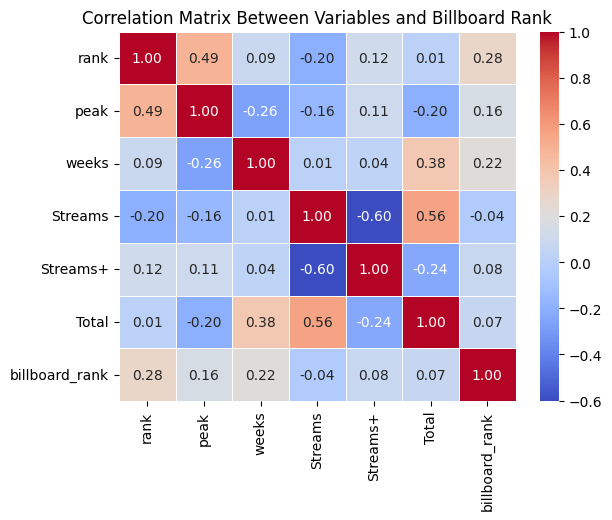

In [396]:
sns.heatmap(bill_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Between Spotify Variables and Billboard Rank")

## By Country

In [ ]:
#Create a pandas series from the total listens dictionary
song_count_series = pd.Series(total_song_count_dic).rename("total_counts")

In [ ]:
song_count_series

In [ ]:
bill_spotify = pd.concat(song_count_spotify_list)

In [374]:
bill_spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
200,1,Bad Bunny,DTMF,1,60,0.001057,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States
419,20,Bad Bunny,DTMF,3,9,0.000151,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom
602,3,Bad Bunny,DTMF,1,60,0.000171,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina
817,18,Bad Bunny,DTMF,3,8,0.000095,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia
1000,1,Bad Bunny,DTMF,1,44,0.000024,-96221.0,4649829,Spotify Weekly Chart Austria,02-26-2026,Austria
...,...,...,...,...,...,...,...,...,...,...,...
11796,197,Lana Del Rey,Young And Beautiful,4,66,0.000005,385.0,972713,Spotify Weekly Chart Singapore,02-26-2026,Singapore
12999,200,Lana Del Rey,Young And Beautiful,131,26,0.000006,-2442.0,1523825,Spotify Weekly Chart Switzerland,02-26-2026,Switzerland
13418,19,UZI,Young And Beautiful,1,5,0.000160,-533917.0,16390266,Spotify Weekly Chart Turkey,02-26-2026,Turkey
13594,195,Poizi,Young And Beautiful,9,44,0.000053,-128838.0,68962002,Spotify Weekly Chart Turkey,02-26-2026,Turkey


In [302]:
#Normalize the total number of streams per 1000000 listens
bill_spotify['Streams'] = bill_spotify["Streams"] / 100000

In [343]:
# For each country available in the spotify weekly charts, compute the total number, the average, and the standard deviation of listens they contributed across all songs in the global billboard hot 200

sum_spotify_country = bill_spotify.groupby("country").sum(numeric_only=True)
mean_spotify_country = bill_spotify.groupby("country").mean(numeric_only=True)
sd_spotify_country = bill_spotify.groupby("country")['Streams'].std()
sd_spotify_song = bill_spotify.groupby("song_name")["Streams"].std()

In [304]:
mean_spotify_country

,rank,peak,weeks,Streams,Streams+,Total
country,,,,,,
Argentina,50.363636,12.666667,50.363636,0.000093,-199516.903226,4.531961e+07
Australia,84.942623,32.959016,92.049180,0.000061,-27070.882353,4.956396e+07
Austria,86.858586,38.595960,62.868687,0.000008,-6391.307692,4.839922e+06
Belarus,97.714286,57.666667,48.761905,0.000002,2077.380952,1.957450e+06
Belgium,78.230000,30.020000,88.770000,0.000015,-10219.010101,1.083593e+07
...,...,...,...,...,...,...
United Kingdom,83.756303,30.369748,86.277311,0.000098,-68169.525424,7.784985e+07
United States,77.017391,22.721739,63.330435,0.000372,-441750.657895,2.431726e+08
Uruguay,53.870968,20.193548,44.709677,0.000007,-10510.580645,3.348443e+06


In [305]:
sum_spotify_country

,rank,peak,weeks,Streams,Streams+,Total
country,,,,,,
Argentina,1662,418,1662,0.003071,-6185024.0,1495546996
Australia,10363,4021,11230,0.007494,-3221435.0,6046802517
Austria,8599,3821,6224,0.000804,-581609.0,479152247
Belarus,2052,1211,1024,0.000052,43625.0,41106456
Belgium,7823,3002,8877,0.001459,-1011682.0,1083592863
...,...,...,...,...,...,...
United Kingdom,9967,3614,10267,0.011676,-8044004.0,9264132457
United States,8857,2613,7283,0.042737,-50359575.0,27964848453
Uruguay,1670,626,1386,0.000218,-325828.0,103801720


In [306]:
sd_spotify_country

country
Argentina         0.000050
Australia         0.000034
Austria           0.000004
Belarus           0.000003
Belgium           0.000007
                    ...   
United Kingdom    0.000056
United States     0.000161
Uruguay           0.000004
Venezuela         0.000007
Vietnam           0.000058
Name: Streams, Length: 72, dtype: float64

In [307]:
sorted_spotify_country = mean_spotify_country["Streams"].sort_values(ascending=False).reset_index()

In [308]:
top_twenty_countries = sorted_spotify_country[0:20]

In [309]:
top_twenty_countries

,country,Streams
0,Mexico,0.000396
1,United States,0.000372
2,Brazil,0.000208
3,Indonesia,0.000159
4,India,0.000143
5,Philippines,0.000130
6,United Kingdom,0.000098
7,Japan,0.000097
8,Argentina,0.000093
9,Turkey,0.000090


In [310]:
reverse_sorted = top_twenty_countries.sort_values(by = "Streams", ascending=True)

In [311]:
sd_top_20 = pd.Series([sd_spotify_country[country_name] for country_name in reverse_sorted['country']])

Text(0.5, 1.0, 'Average Weekly Number of Streams by Country (Top 20 Countries)')

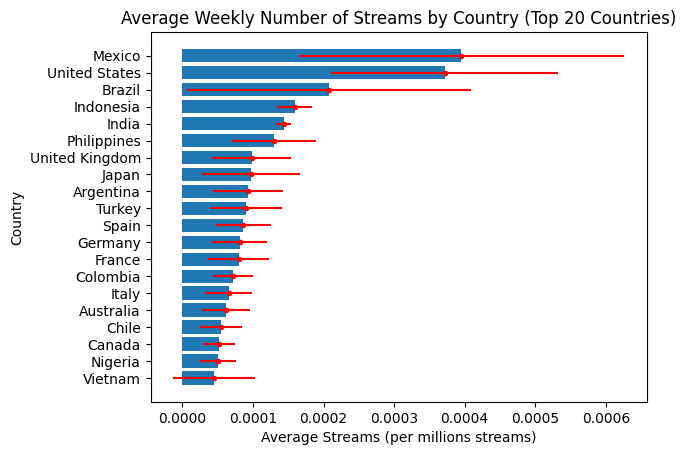

In [312]:
plt.barh(y = reverse_sorted.iloc[0:20, 0], width = reverse_sorted.iloc[0:20, 1], align = 'center')
plt.xlabel("Average Streams (per millions streams)")
plt.ylabel("Country")
plt.errorbar(y = reverse_sorted.iloc[0:20, 0], x = reverse_sorted.iloc[0:20, 1], xerr= sd_top_20, color = 'r', fmt='.')
plt.title("Average Weekly Number of Streams by Country (Top 20 Countries)")

In [313]:
sum_sorted_spotify_country = sum_spotify_country["Streams"].sort_values(ascending=False).reset_index()

In [314]:
sum_top_twenty_countries = sum_sorted_spotify_country[0:20]

In [315]:
sum_reverse_sorted = sum_top_twenty_countries.sort_values(by = "Streams", ascending=True)

Text(0.5, 1.0, 'Total Weekly Number of Streams by Country (Top 20 Countries)')

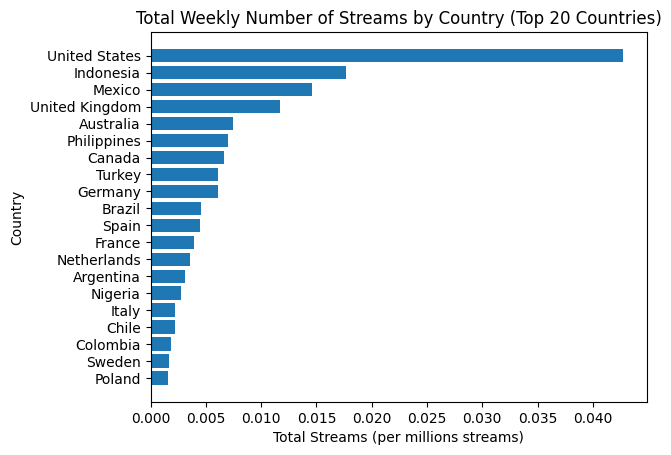

In [316]:
plt.barh(y = sum_reverse_sorted.iloc[0:20, 0], width = sum_reverse_sorted.iloc[0:20, 1], align = 'center')
plt.xlabel("Total Streams (per millions streams)")
plt.ylabel("Country")
plt.title("Total Weekly Number of Streams by Country (Top 20 Countries)")

## By Song Name

In [317]:
song_average_all_countries_spotify = bill_spotify.groupby("song_name").mean(numeric_only=True).reset_index().sort_values("song_name")

In [318]:
billboard_rank_df = pd.Series(billboard_rank).to_frame().reset_index()

In [319]:
song_average_all_countries_spotify['billboard_rank'] = billboard_rank_df.sort_values("index").reset_index(drop=True)[0]

In [320]:
song_average_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
0,(When You Gonna) Give It Up To Me,78.595238,68.000000,9.071429,0.000026,-12397.975000,4.284574e+06,102
1,12 To 12,38.714286,20.357143,29.821429,0.000044,-19558.035714,1.365062e+07,26
2,4 Raws,93.761905,29.904762,16.190476,0.000030,-25515.857143,5.481212e+06,125
3,505,122.800000,31.300000,199.500000,0.000051,-33513.200000,1.023471e+08,132
4,7-3,22.400000,11.600000,9.000000,0.000163,-195038.000000,1.729392e+07,116
...,...,...,...,...,...,...,...,...
194,Young And Beautiful,135.888889,49.111111,46.111111,0.000052,-82291.888889,5.890100e+07,74
195,Yukon,139.400000,23.300000,22.100000,0.000046,-63488.800000,1.990086e+07,200
196,Zoo,91.307692,46.923077,20.769231,0.000027,-20558.076923,1.192589e+07,79
197,like JENNIE,76.111111,3.000000,67.000000,0.000027,-8996.333333,5.245837e+07,65


In [321]:
song_average_all_countries_spotify.sort_values("rank", ascending = True)

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
91,La Villa,21.105263,9.368421,20.263158,0.000066,-13756.421053,2.640014e+07,95
4,7-3,22.400000,11.600000,9.000000,0.000163,-195038.000000,1.729392e+07,116
41,DTMF,23.966667,7.833333,33.766667,0.000071,-227255.650000,2.320823e+07,1
39,Cuando No Era Cantante,29.371429,16.857143,15.942857,0.000068,-58205.742857,1.566829e+07,92
21,Be Her,30.500000,28.500000,2.000000,0.000271,-157233.000000,5.580218e+06,54
...,...,...,...,...,...,...,...,...
193,Yo Perreo Sola,164.000000,25.333333,93.166667,0.000039,-47582.000000,8.333611e+07,67
70,Greedy,167.500000,18.125000,98.250000,0.000018,-22997.666667,3.884753e+07,162
160,Take On Me,169.833333,165.833333,3.000000,0.000011,5342.000000,3.014447e+05,194
14,As It Was,171.000000,1.000000,147.090909,0.000014,-6166.875000,4.817819e+07,107


Text(0.5, 1.0, 'Song Rank v. Streams')

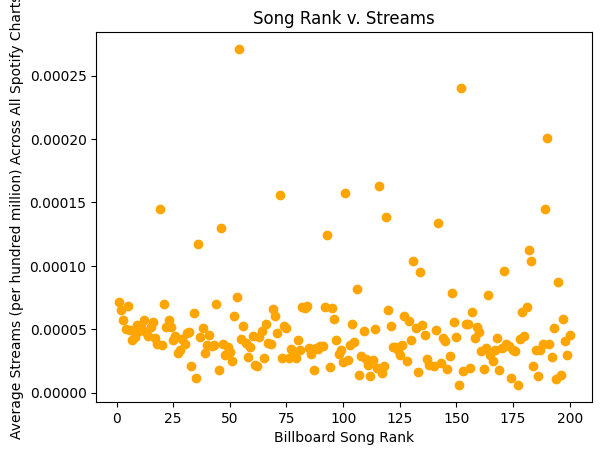

In [322]:
plt.scatter(song_average_all_countries_spotify['billboard_rank'], song_average_all_countries_spotify["Streams"], color = "orange")

plt.xlabel("Billboard Song Rank")
plt.ylabel("Average Streams (per hundred million) Across All Spotify Charts")
plt.title("Song Rank v. Streams")

Text(0.5, 1.0, 'Song Rank v. Streams')

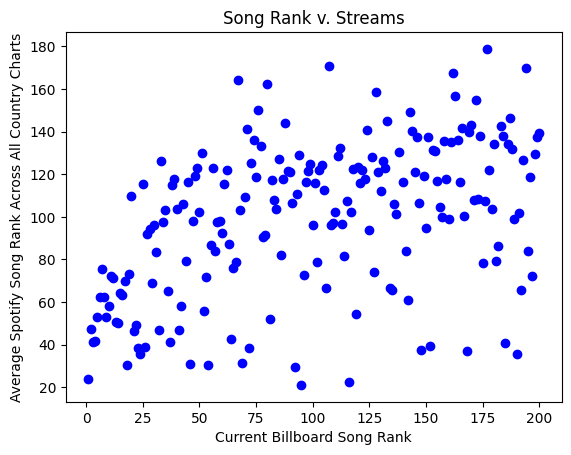

In [323]:
plt.scatter(song_average_all_countries_spotify['billboard_rank'], song_average_all_countries_spotify["rank"], color = "blue")

plt.xlabel("Current Billboard Song Rank")
plt.ylabel("Average Spotify Song Rank Across All Country Charts")
plt.title("Song Rank v. Streams")

In [333]:
song_sum_all_countries_spotify = bill_spotify.groupby("song_name").sum(numeric_only=True).sort_values("song_name").reset_index()

In [334]:
song_sum_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total
0,(When You Gonna) Give It Up To Me,3301,2856,381,0.001073,-495919.0,179952107
1,12 To 12,1084,570,835,0.001240,-547625.0,382217227
2,4 Raws,1969,628,340,0.000626,-535833.0,115105457
3,505,1228,313,1995,0.000506,-335132.0,1023470809
4,7-3,112,58,45,0.000814,-975190.0,86469621
...,...,...,...,...,...,...,...
194,Young And Beautiful,1223,442,415,0.000470,-740627.0,530108959
195,Yukon,1394,233,221,0.000458,-634888.0,199008629
196,Zoo,1187,610,270,0.000354,-267255.0,155036610
197,like JENNIE,685,27,603,0.000242,-80967.0,472125324


In [335]:
billboard_rank_df.sort_values("index").reset_index(drop=True)[0]

0      102
1       26
2      125
3      132
4      116
      ... 
195    200
196     79
197     65
198    153
199    139
Name: 0, Length: 200, dtype: int64

In [336]:
song_sum_all_countries_spotify['billboard_rank'] = billboard_rank_df.sort_values("index").reset_index(drop=True)[0]

In [337]:
song_sum_all_countries_spotify

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
0,(When You Gonna) Give It Up To Me,3301,2856,381,0.001073,-495919.0,179952107,102
1,12 To 12,1084,570,835,0.001240,-547625.0,382217227,26
2,4 Raws,1969,628,340,0.000626,-535833.0,115105457,125
3,505,1228,313,1995,0.000506,-335132.0,1023470809,132
4,7-3,112,58,45,0.000814,-975190.0,86469621,116
...,...,...,...,...,...,...,...,...
194,Young And Beautiful,1223,442,415,0.000470,-740627.0,530108959,74
195,Yukon,1394,233,221,0.000458,-634888.0,199008629,200
196,Zoo,1187,610,270,0.000354,-267255.0,155036610,79
197,like JENNIE,685,27,603,0.000242,-80967.0,472125324,65


Text(0.5, 1.0, 'Song Rank v. Streams')

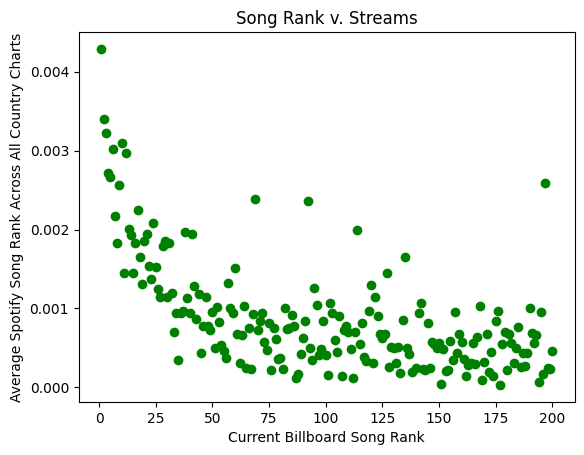

In [338]:
plt.scatter(song_sum_all_countries_spotify['billboard_rank'], song_sum_all_countries_spotify["Streams"], color = "green")

plt.xlabel("Current Billboard Song Rank")
plt.ylabel("Average Spotify Song Rank Across All Country Charts")
plt.title("Song Rank v. Streams")

In [346]:
top_20_sum = song_sum_all_countries_spotify.sort_values("Streams", ascending = False)[0:20]

In [352]:
top_20_sum

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
41,DTMF,1438,470,2026,0.004290,-13635339.0,1392493831,1
18,Baile Inolvidable,2467,842,1760,0.003398,-9966194.0,1560138836,2
116,Nuevayol,2301,759,1928,0.003222,-10073727.0,1375305328,3
57,End Of Beginning,3725,965,3399,0.003101,-1920299.0,1679010913,10
165,The Fate Of Ophelia,3794,435,1578,0.003016,-1513191.0,1480958956,6
147,So Easy (To Fall In Love),3707,2941,1057,0.002967,-540358.0,955962055,12
172,Titi Me Pregunto,2262,831,2024,0.002717,-9888310.0,1308378181,4
100,Man I Need,2064,1438,912,0.002662,-1470640.0,683845558,5
188,Who,3248,1371,3276,0.002596,-206253.0,1589262423,197
56,EOO,2541,1093,1507,0.002559,-7571834.0,916849652,9


In [347]:
reverse_sorted_sum = top_20_sum.sort_values(by = "Streams", ascending=True)

In [349]:
reverse_sorted_sum

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
15,Babydoll,2017,1649,745,0.001942,1640979.0,700457134,41
47,Die On This Hill,1305,897,495,0.001948,-714494.0,593779731,21
26,Body,4488,2007,1781,0.001975,-1246805.0,1280382341,38
82,Iris Out,3266,2047,3790,0.001996,-1162254.0,1504729549,114
187,Where Is My Husband!,2132,1184,905,0.002011,-1588582.0,500632567,13
154,Stateside,1431,1422,276,0.002084,6618554.0,98104088,24
68,Golden,3932,1347,1815,0.002177,-1777000.0,1546643398,7
16,Back To Friends,3627,1736,2321,0.002246,-720420.0,1266609260,17
39,Cuando No Era Cantante,1028,590,558,0.002367,-2037201.0,548390247,92
40,Cuando No Era Cantante (Remix),1130,594,576,0.002386,-2011152.0,554824333,69


In [350]:
sd_top_20_sum = pd.Series([sd_spotify_song[country_name] for country_name in reverse_sorted_sum['song_name']])

In [355]:
top_20_bill_rank = song_sum_all_countries_spotify.sort_values("billboard_rank", ascending = True)[0:20]

In [360]:
top_20_bill_rank

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
41,DTMF,1438,470,2026,0.004290,-13635339.0,1392493831,1
18,Baile Inolvidable,2467,842,1760,0.003398,-9966194.0,1560138836,2
116,Nuevayol,2301,759,1928,0.003222,-10073727.0,1375305328,3
172,Titi Me Pregunto,2262,831,2024,0.002717,-9888310.0,1308378181,4
100,Man I Need,2064,1438,912,0.002662,-1470640.0,683845558,5
165,The Fate Of Ophelia,3794,435,1578,0.003016,-1513191.0,1480958956,6
68,Golden,3932,1347,1815,0.002177,-1777000.0,1546643398,7
123,Ordinary,2628,731,2102,0.001830,-1823993.0,1431839521,8
56,EOO,2541,1093,1507,0.002559,-7571834.0,916849652,9
57,End Of Beginning,3725,965,3399,0.003101,-1920299.0,1679010913,10


In [363]:
reverse_sorted_sum_bil_rank = top_20_bill_rank.sort_values(by = "billboard_rank", ascending=False)

In [364]:
reverse_sorted_sum_bil_rank

,song_name,rank,peak,weeks,Streams,Streams+,Total,billboard_rank
48,Die With A Smile,5389,234,3985,0.001854,-1864015.0,3387850153,20
32,Choosin' Texas,658,584,226,0.001304,-249712.0,268436385,19
133,Raindance,1313,1087,498,0.001647,-717975.0,191855339,18
16,Back To Friends,3627,1736,2321,0.002246,-720420.0,1266609260,17
179,Voy A Llevarte Pa PR,2082,605,1528,0.001832,-5899767.0,1142999717,16
76,I Just Might,1797,636,196,0.001445,-298803.0,133504359,15
98,Lush Life,2150,740,4125,0.001927,-1806760.0,1162669437,14
187,Where Is My Husband!,2132,1184,905,0.002011,-1588582.0,500632567,13
147,So Easy (To Fall In Love),3707,2941,1057,0.002967,-540358.0,955962055,12
122,Opalite,2026,199,760,0.001448,-1075459.0,905001381,11


In [357]:
sd_top_20_sum_bill_rank = pd.Series([sd_spotify_song[country_name] for country_name in reverse_sorted_sum_bil_rank['song_name']])

Text(0.5, 1.0, 'Total Weekly Number of Streams by Song (Top 20 Songs by Streams)')

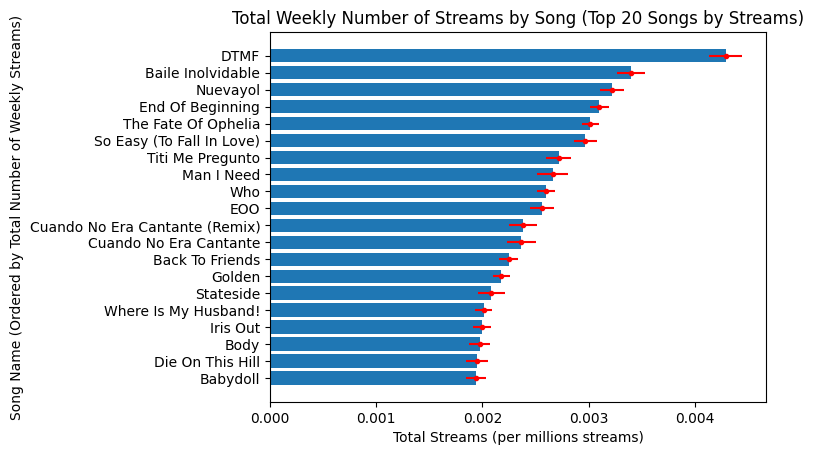

In [368]:
plt.barh(y = reverse_sorted_sum.iloc[0:20, 0], width = reverse_sorted_sum.iloc[0:20, 4], align = 'center')
plt.xlabel("Total Streams (per millions streams)")
plt.ylabel("Song Name (Ordered by Total Number of Weekly Streams)")
plt.errorbar(y = reverse_sorted_sum.iloc[0:20, 0], x = reverse_sorted_sum.iloc[0:20, 4], xerr= sd_top_20_sum, color = 'r', fmt='.')
plt.title("Total Weekly Number of Streams by Song (Top 20 Songs by Streams)")

Text(0.5, 1.0, 'Total Weekly Number of Streams by Song (Top 20 Songs by Global Billboard Ranking)')

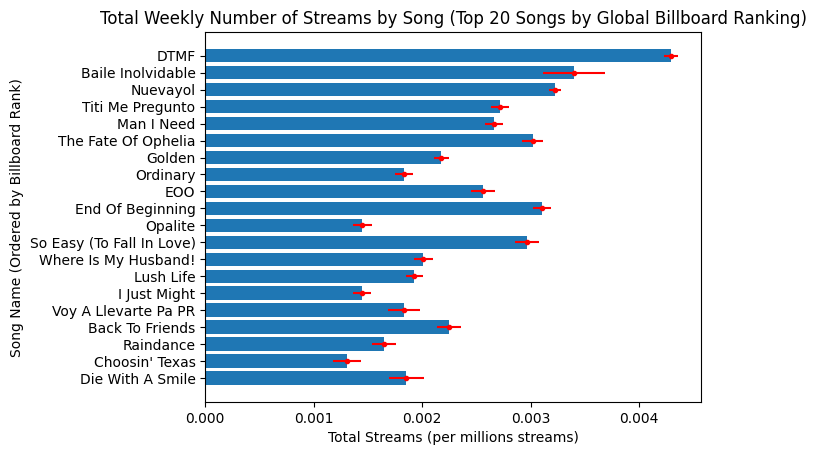

In [371]:
plt.barh(y = reverse_sorted_sum_bil_rank.iloc[0:20, 0], width = reverse_sorted_sum_bil_rank.iloc[0:20, 4], align = 'center')
plt.xlabel("Total Streams (per millions streams)")
plt.ylabel("Song Name (Ordered by Billboard Rank)")
plt.errorbar(y = reverse_sorted_sum_bil_rank.iloc[0:20, 0], x = reverse_sorted_sum_bil_rank.iloc[0:20, 4], xerr= sd_top_20_sum_bill_rank, color = 'r', fmt='.')
plt.title("Total Weekly Number of Streams by Song (Top 20 Songs by Global Billboard Ranking)")

## CSV

In [402]:
apple_csv = pd.read_csv("../Final_Project/all_data/apple_chart_concentration_measures.csv")

In [403]:
spotify_csv = pd.read_csv("../Final_Project/all_data/spotify_weekly_concentration_measures.csv")

In [430]:
spotify_csv

,chart_name,HHI,CR3,Gini
0,Spotify Weekly Chart El Salvador,0.04775,0.310,0.510260
1,Spotify Weekly Chart Israel,0.04400,0.270,0.497561
2,Spotify Weekly Chart Venezuela,0.04385,0.310,0.511528
3,Spotify Weekly Chart Honduras,0.04010,0.275,0.493580
4,Spotify Weekly Chart Dominican Republic,0.03895,0.275,0.505897
...,...,...,...,...
72,Spotify Weekly Chart Austria,0.01015,0.095,0.236458
73,Spotify Weekly Chart Kazakhstan,0.00965,0.080,0.235493
74,Spotify Weekly Chart Malta,0.00950,0.065,0.236224
75,Spotify Weekly Chart Malaysia,0.00865,0.075,0.201854


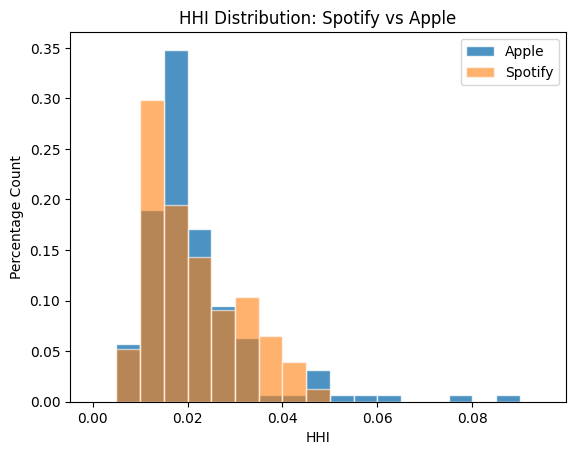

In [451]:
plt.hist(apple_csv["HHI"],  bins = np.arange(0, 0.1, 0.005), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["HHI"], bins = np.arange(0, 0.1, 0.005), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, edgecolor = "white", label = "Spotify")
plt.xlabel("HHI")
plt.ylabel("Percentage Count")
plt.title("HHI Distribution: Spotify vs Apple")
plt.legend()

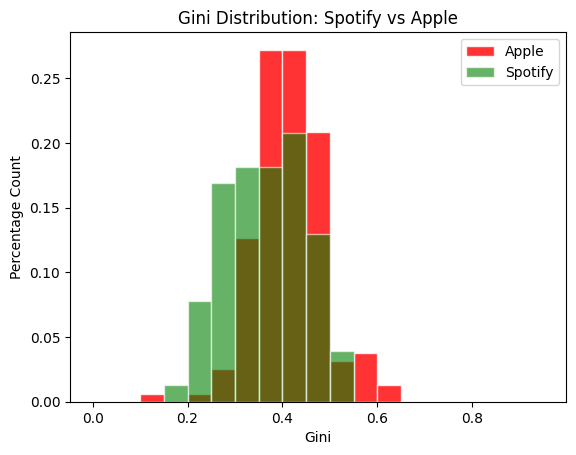

In [432]:
plt.hist(apple_csv["Gini"],  bins = np.arange(0, 1, 0.05), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, color = "red", edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["Gini"], bins = np.arange(0, 1, 0.05), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, color = "green", edgecolor = "white", label = "Spotify")
plt.xlabel("Gini")
plt.ylabel("Percentage Count")
plt.title("Gini Distribution: Spotify vs Apple")
plt.legend()

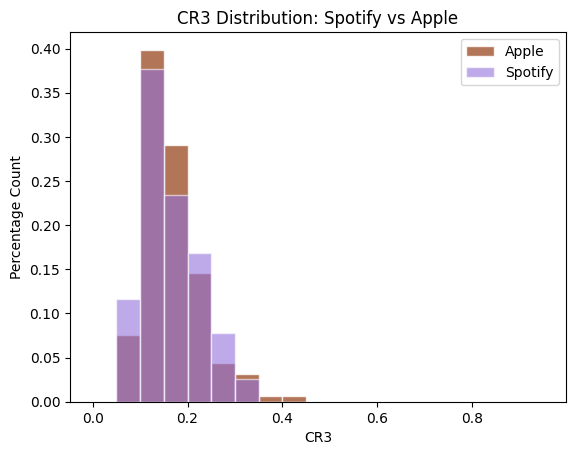

In [448]:
plt.hist(apple_csv["CR3"],  bins = np.arange(0, 1, 0.05), weights=np.ones(len(apple_csv)) / len(apple_csv), alpha = 0.8, color = "sienna", edgecolor = "white", label = "Apple")
plt.hist(spotify_csv["CR3"], bins = np.arange(0, 1, 0.05), weights=np.ones(len(spotify_csv)) / len(spotify_csv), alpha = 0.6, color = "mediumpurple", edgecolor = "white", label = "Spotify")
plt.xlabel("CR3")
plt.ylabel("Percentage Count")
plt.title("CR3 Distribution: Spotify vs Apple")
plt.legend()